# Comparison between algorithms

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import time
import sys

sys.path.append(os.path.abspath(".."))   # Add root path to sys.path
os.chdir("..")  # Change working directory to root path

from tqdm import tqdm
from datetime import datetime

### Nowcasting result

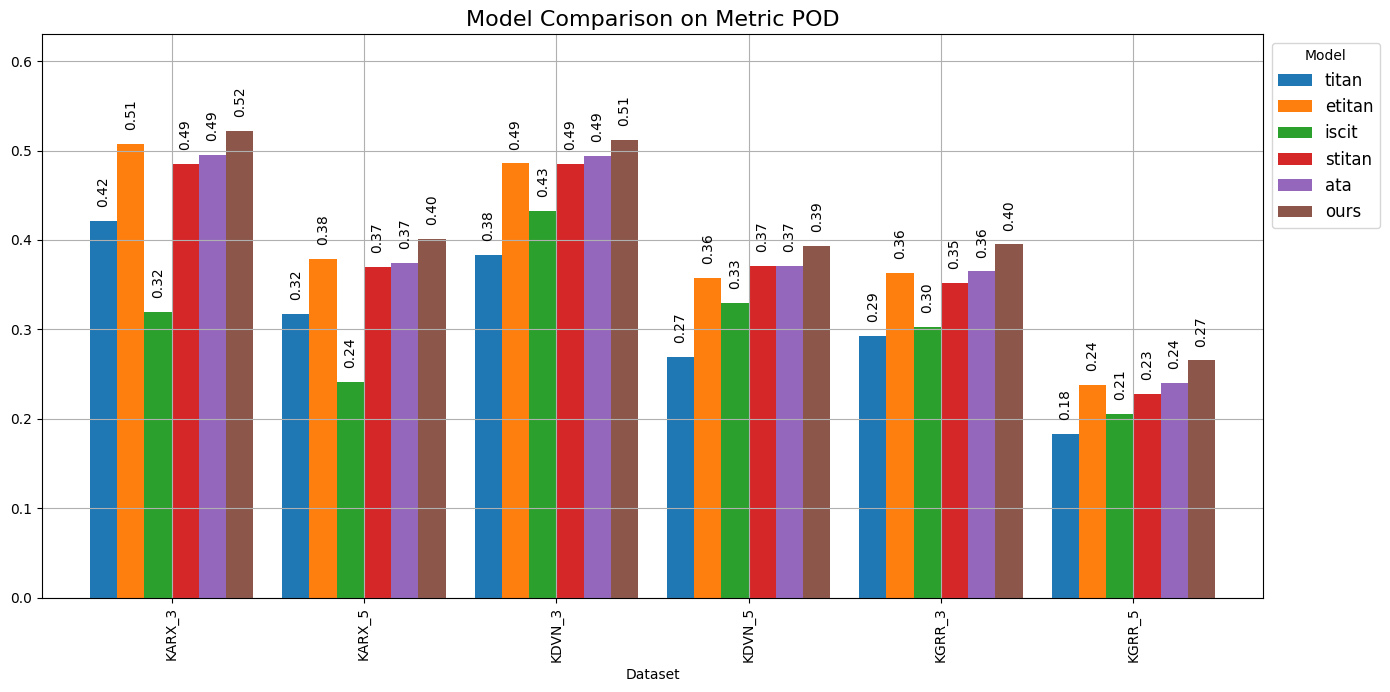

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

MODEL_NAME = ['titan', 'etitan', 'iscit', 'stitan', 'ata', 'ours']
TIME_INTERVALS = [3, 5]
METRIC = 'pod'

# 1. Load the data
datasets = ["KARX", "KDVN", "KGRR"]
datasets_names = [f"{d}_{idx}" for d in datasets for idx in TIME_INTERVALS]

dataframe = pd.DataFrame(columns=['Dataset'] + MODEL_NAME)

for dataset in datasets:
    file_path = f"data/tracking_output/{dataset}_models_evaluation.csv"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    
    df = pd.read_csv(file_path)
    df.set_index('model_name', inplace=True)
    df = df.loc[MODEL_NAME, :]

    
    for ti in TIME_INTERVALS:
        temp_df = df[f'{METRIC}_{ti}']
        row = {'Dataset': f"{dataset}_{ti}"}
        for model_name, value in zip(MODEL_NAME, temp_df):
            row[model_name] = value
        dataframe.loc[len(dataframe)] = row

dataframe = dataframe.set_index('Dataset')

# 1. Plot with the width adjustment
ax = dataframe.plot(
    kind='bar', 
    figsize=(14, 7), 
    width=0.85, # Adjusted to minimize "wasted space"
    title=f'Metric {METRIC}', 
    grid=True, 
    fontsize=10
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', rotation=90, padding=10, fontsize=10)

# 4. Give the vertical labels some breathing room at the top
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.title(f'Model Comparison on Metric {METRIC.upper()}', fontsize=16)

plt.savefig(f'output/tracking/nowcasting_{METRIC.upper()}_comparison.png')
plt.show()

### Tracking Results

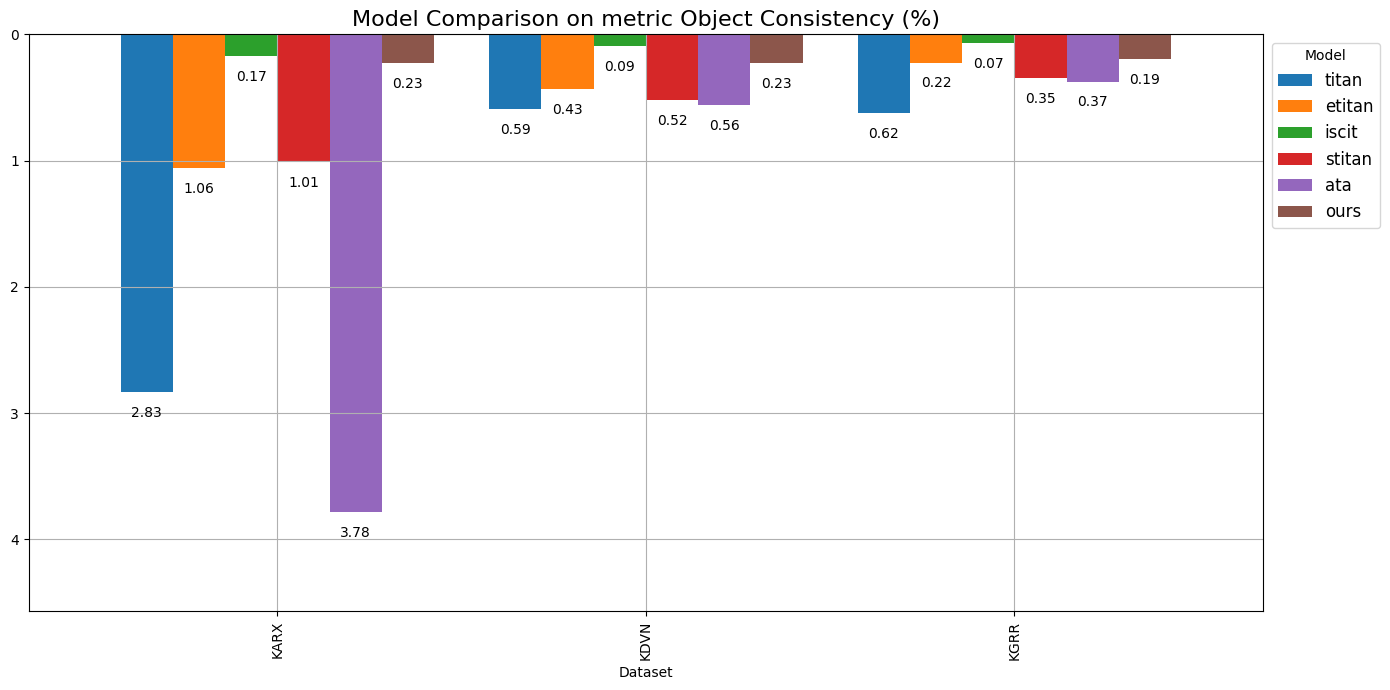

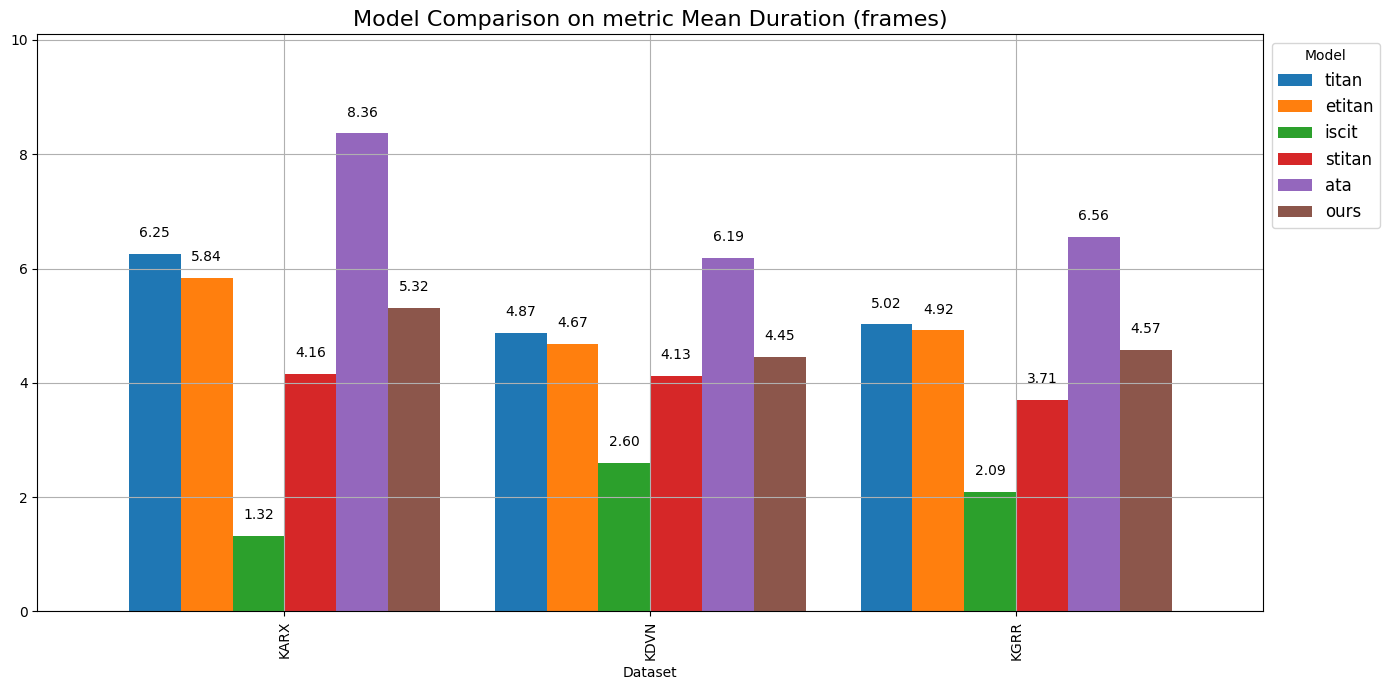

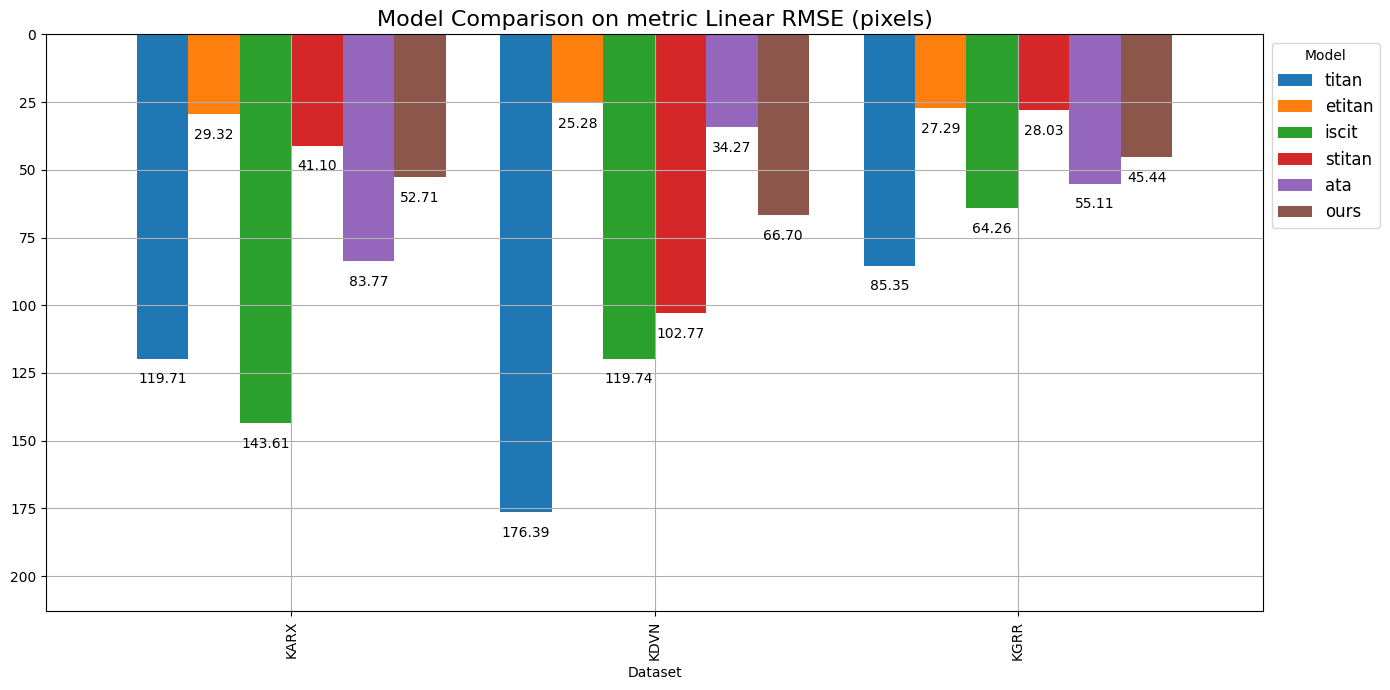

In [3]:
# 1. Load the tracking result
datasets = ["KARX", "KDVN", "KGRR"]

tracking_metrics = ["Object Consistency", "Mean Duration", "Linear RMSE", "Optimal Tracking"]
tracking_columns = ["object_consistency", "mean_duration", "linear_rmse", "optimal_tracking"]
units = ["(%)", "(frames)", "(pixels)", "(score)"]

for idx in range(3):
    IDX = idx
    dataframe = pd.DataFrame(columns=['Dataset'] + MODEL_NAME)

    for dataset in datasets:
        file_path = f"data/tracking_output/{dataset}_models_evaluation.csv"
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")
        
        df = pd.read_csv(file_path)
        df.set_index('model_name', inplace=True)
        df = df.loc[MODEL_NAME, :]

        
        temp_df = df[tracking_columns[IDX]]
        row = {'Dataset': dataset}
        for model_name, value in zip(MODEL_NAME, temp_df):
            row[model_name] = value
        dataframe.loc[len(dataframe)] = row

    dataframe.set_index('Dataset', inplace=True)

    # 1. Plot with the width adjustment
    ax = dataframe.plot(
        kind='bar', 
        figsize=(14, 7), 
        width=0.85, # Adjusted to minimize "wasted space"
        grid=True, 
        fontsize=10
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=10 if IDX % 2 == 1 else -20, fontsize=10)

    # 4. Give the vertical labels some breathing room at the top
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

    plt.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left', fontsize=12)
    plt.title(f'Model Comparison on metric {tracking_metrics[IDX]} {units[IDX]}', fontsize=16)
    plt.tight_layout()

    if IDX % 2 == 0:
        plt.ylim(reversed(plt.ylim()))

    plt.savefig(f'output/tracking/tracking_{tracking_metrics[IDX].replace(" ", "_").lower()}_comparison.png')
plt.show()